In [1]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
from matplotlib.ticker import LogLocator, LogFormatterMathtext


# ============================================================
# Constants (paper) - Normaal direct vanuit paper
# ============================================================
C_LIGHT = 299_792_458.0
L_ARM   = 2.5e9
F_STAR  = C_LIGHT / (2.0*np.pi*L_ARM)

MPC_M     = 3.0856775814913673e22
H0_OVER_h = (100.0 * 1000.0) / MPC_M

P_OMS_PM = 15.0
A_ACC_FM = 3.0

# Schaal factor Y00
Y00 = 1.0 / np.sqrt(4.0*np.pi)

# ============================================================
# Appendix B: Noise functions
# ============================================================
def S_oms(f):
    f = np.asarray(f, float)
    return (P_OMS_PM * 1e-12)**2 * (1.0 + (2.0e-3 / f)**4)

def S_acc(f):
    f = np.asarray(f, float)
    return (A_ACC_FM * 1e-15)**2 * (1.0 + (0.4e-3 / f)**2) * (1.0 + (f / 8.0e-3)**4)

def N_tilde_AE(f):
    f = np.asarray(f, float)
    x = f / F_STAR
    cosx = np.cos(x)
    term_oms = 0.5 * (2.0 + cosx) * (S_oms(f) / L_ARM**2)
    term_acc = 2.0 * (1.0 + cosx + cosx**2) * (S_acc(f) / L_ARM**2) * (1.0/(2.0*np.pi*f))**4
    return term_oms + term_acc

def N_tilde_T(f):
    f = np.asarray(f, float)
    x = f / F_STAR
    one_minus_cos = 1.0 - np.cos(x)
    term_oms = one_minus_cos * (S_oms(f) / L_ARM**2)
    term_acc = 2.0 * (one_minus_cos**2) * (S_acc(f) / L_ARM**2) * (1.0/(2.0*np.pi*f))**4
    return term_oms + term_acc

# ============================================================
# Appendix A helper functies (deze misten denk ik ook de vorige implementatie)
# ============================================================
def sinc(x):
    x = np.asarray(x)
    out = np.ones_like(x, dtype=np.complex128)
    small = np.abs(x) < 1e-12
    xs = x[~small]
    out[~small] = np.sin(xs) / xs
    return out

def M_transfer(u, mu):
    arg = 0.5 * u * (1.0 + mu)
    return np.exp(1j * arg) * sinc(arg)

def T_transfer(u, mu):
    return np.exp(-1j*u) * M_transfer(u, -mu) + np.exp(-1j*u*mu) * M_transfer(u, mu)

# ============================================================
# Polarization tensors and projections on a HEALPix grid (aangepast door ChatGPT, ik was de som over de twee polarisaties miss vergeten) 
# ============================================================
def healpix_grid(nside):
    npix = hp.nside2npix(nside)
    theta, phi = hp.pix2ang(nside, np.arange(npix), nest=False)
    sin_t = np.sin(theta)
    khat = np.stack([sin_t*np.cos(phi), sin_t*np.sin(phi), np.cos(theta)], axis=1)
    return khat, theta, phi

def polarization_tensors_from_k(khat, theta, phi):
    e_theta = np.stack([np.cos(theta)*np.cos(phi),
                        np.cos(theta)*np.sin(phi),
                        -np.sin(theta)], axis=1)
    e_phi = np.stack([-np.sin(phi),
                      np.cos(phi),
                      np.zeros_like(phi)], axis=1)
    e_plus  = e_theta[:, :, None]*e_theta[:, None, :] - e_phi[:, :, None]*e_phi[:, None, :]
    e_cross = e_theta[:, :, None]*e_phi[:, None, :]   + e_phi[:, :, None]*e_theta[:, None, :]
    return e_plus, e_cross

def g_pol_from_arm(lhat, e_tensor):
    return 0.5 * np.einsum("i,j,nij->n", lhat, lhat, e_tensor)

# ============================================================
# A,E,T channel mixing (paper Eq. 4.25) - De onderstaande matrix zijn de constanten die daar staan voor F1, F2 en F3
# ============================================================
C_AET = np.array([
    [-1/np.sqrt(2),  0.0,           1/np.sqrt(2)],  # A
    [ 1/np.sqrt(6), -2/np.sqrt(6),  1/np.sqrt(6)],  # E
    [ 1/np.sqrt(3),  1/np.sqrt(3),  1/np.sqrt(3)],  # T
], dtype=float)
O_list = ["A", "E", "T"]
O_idx  = {O: i for i, O in enumerate(O_list)}

# ============================================================
# Sensitivity equations (paper Eqs. 4.42-4.43) letterlijk gwn de formules net boven Figuur 9. (NOTE VOOR BERT - zou het kunnen dat we de
# de channels dubbel moeten tellen aangezien we AE en EA , ... hebben? Die factor van twee (1.0 / np.sqrt(inv2) --> 2.0 / np.sqrt(inv2)
# fixt het probleem (normaal gezien), en doordat de onderstaande functie een beetje herschreven is ben ik niet zeker of al die channels appart geteld worden.
# Ik denk dat de code gebruik maakt van de symmetrie van de kanalen en dus AE = EA doet, maar dan miss wel maar alleen AE telt... Zal
# zelf ook nog nagaan maar had ff druk. Een andere oplossing kon zijn dat een van de schaalfactoren miss in de verkeerde plaats stond en 
# zo te veel werd meegeteld ofs maar ik denk dat de schaalfactoren eig wel op de juiste plaats staan. 
# ============================================================
def omega_channel_channel(f, Rtilde, Ntilde_O, Ntilde_Op):
    pref = (4.0*np.pi**2 * np.sqrt(4.0*np.pi)) / (3.0 * (H0_OVER_h**2))
    return pref * (f**3) * (np.sqrt(Ntilde_O * Ntilde_Op) / Rtilde)

def optimal_omega_from_ordered_pairs(omega_pairs_9):
    inv2 = np.zeros_like(omega_pairs_9[0], dtype=float)
    for om in omega_pairs_9:
        inv2 += 1.0 / (om*om)
    return 1.0 / np.sqrt(inv2)

def power_law_omega_gw_h2(f, amplitude_h2=1.0e-12, alpha=0.65, f_ref=2.5e-3):
    f = np.asarray(f, float)
    return amplitude_h2 * (f / f_ref)**alpha

def _evaluate_omega_gw_h2(f_grid, omega_gw_h2):
    if callable(omega_gw_h2):
        values = np.asarray(omega_gw_h2(f_grid), dtype=float)
    else:
        values = np.asarray(omega_gw_h2, dtype=float)
        if values.shape != f_grid.shape:
            raise ValueError("If omega_gw_h2 is an array, it must have the same shape as f_grid.")
    return values

def _resolve_c_ell_gw(c_ell_gw, ell):
    if c_ell_gw is None:
        return 1.0
    if np.isscalar(c_ell_gw):
        value = float(c_ell_gw)
    elif isinstance(c_ell_gw, dict):
        value = float(c_ell_gw.get(ell, 0.0))
    else:
        values = np.asarray(c_ell_gw, dtype=float)
        if ell >= values.size:
            raise ValueError("c_ell_gw must contain a value for every requested multipole.")
        value = float(values[ell])
    if value < 0.0:
        raise ValueError("Eq. (4.44) needs C_ell^GW >= 0 for every multipole.")
    return value

def compute_snr_per_multipole_eq444(
    f_grid,
    raw_sensitivity_by_ell,
    omega_gw_h2,
    c_ell_gw=None,
    t_obs_yr=4.0,
    fmin=None,
    fmax=None,
):
    r"""
    Exact implementation of Eq. (4.44):

      <SNR>_ell^2 = T \int df
                    [ sqrt(C_ell^GW) * Omega_GW(f) h^2
                      / Omega_{GW,n}^ell(f) h^2 ]^2

    The denominator must be the raw Eq. (4.43) sensitivity, not the Figure 9
    curve divided by sqrt(4*pi).
    """
    f = np.asarray(f_grid, dtype=float)
    if np.any(np.diff(f) <= 0.0):
        raise ValueError("f_grid must be strictly increasing.")

    omega_gw_vals = _evaluate_omega_gw_h2(f, omega_gw_h2)
    t_obs_sec = float(t_obs_yr * 365.25 * 24.0 * 3600.0)

    band = np.ones_like(f, dtype=bool)
    if fmin is not None:
        band &= f >= float(fmin)
    if fmax is not None:
        band &= f <= float(fmax)
    if np.count_nonzero(band) < 2:
        raise ValueError("The selected frequency band must contain at least two grid points.")

    ells = np.array(sorted(raw_sensitivity_by_ell.keys()), dtype=int)
    snr2 = np.zeros_like(ells, dtype=float)
    integrands = {}

    for i, ell in enumerate(ells):
        c_ell = _resolve_c_ell_gw(c_ell_gw, ell)
        omega_sig_ell = np.sqrt(c_ell) * omega_gw_vals
        omega_noise_ell = np.asarray(raw_sensitivity_by_ell[ell], dtype=float)
        if omega_noise_ell.shape != f.shape:
            raise ValueError(f"Sensitivity curve for ell={ell} does not match f_grid.")

        integrand = np.zeros_like(f, dtype=float)
        mask = band & np.isfinite(omega_sig_ell) & np.isfinite(omega_noise_ell) & (omega_noise_ell > 0.0)
        if np.count_nonzero(mask) >= 2:
            integrand[mask] = (omega_sig_ell[mask] / omega_noise_ell[mask])**2
            snr2[i] = float(t_obs_sec * np.trapezoid(integrand[mask], f[mask]))
        integrands[ell] = integrand

    return {
        "ells": ells,
        "snr2": snr2,
        "snr": np.sqrt(snr2),
        "integrands": integrands,
        "omega_gw_h2": omega_gw_vals,
    }

def print_snr_table(snr_results):
    print(f"{'ell':>3} {'SNR^2':>16} {'SNR':>16}")
    for ell, snr2, snr in zip(snr_results["ells"], snr_results["snr2"], snr_results["snr"]):
        print(f"{ell:3d} {snr2:16.8e} {snr:16.8e}")

# ============================================================
# Key point for "real basis" + iter=1 with complex sky maps
# ============================================================
# healpy.map2alm(...) assumes a *real* map (standard use case).
# Our per-frequency sky maps are complex because of exp(-2π i f k·Δx).
#
# To use healpy's SHT machinery (and thus iter=1) while keeping the *full*
# complex harmonic content, we compute:
#   a_{lm}^*basis  = ∫ f(Ω) Y_{lm}^*(Ω) dΩ  via map2alm(Re f) + i map2alm(Im f)
# and also
#   b_{lm}         = ∫ f(Ω) Y_{lm}(Ω)  dΩ  via map2alm(Re f) - i map2alm(Im f) but with
# the correct operation: b_{lm} = (∫ f*(Ω) Y_{lm}^*(Ω) dΩ)^*.
#
# For any complex f:
#   c_{lm} := ∫ f*(Ω) Y_{lm}^*(Ω) dΩ
# then
#   b_{lm} = c_{lm}^*.
#
# So we compute:
#   alm_f  = map2alm(Re f) + i map2alm(Im f)         (m>=0 stored)
#   alm_fc = map2alm(Re f) - i map2alm(Im f)         equals map2alm(conj(f)) (linearity)
# and use:
#   power_l = |a_{l0}|^2 + sum_{m=1..l} ( |a_{lm}|^2 + |c_{lm}|^2 )
# where c_{lm} are the coefficients from alm_fc (since alm_fc = c_{lm} for m>=0).
#
# This quantity equals sum_{m=-l..l} |Z_{lm}|^2 for the complex-harmonic basis,
# i.e. the rotation-invariant response used in the paper.
#
# ============================================================

# cDit (bovenstaande uitleg) was de belangrijkste additie van ChatGPT, het was op deze plaats in de code datik dingen had geporbeerd te fixen
# maar vond het niet... de logica is niet veel veranderd maar de implementatie is gewoon verbeterd, vooral die van de spherical harmonics.

def precompute_alm_indices(lmax):
    idx_by_ell = {}
    idx_mpos_by_ell = {}
    for ell in range(lmax + 1):
        idxs = [hp.Alm.getidx(lmax, ell, m) for m in range(0, ell + 1)]
        idx_by_ell[ell] = np.array(idxs, dtype=np.int64)
        if ell >= 1:
            idxs_mpos = [hp.Alm.getidx(lmax, ell, m) for m in range(1, ell + 1)]
            idx_mpos_by_ell[ell] = np.array(idxs_mpos, dtype=np.int64)
        else:
            idx_mpos_by_ell[ell] = np.array([], dtype=np.int64)
    return idx_by_ell, idx_mpos_by_ell

def compute_lisa_multipole_sensitivity(f_grid, lmax=10, nside=32, iter_sht=1):
    """
    Uses healpy's spherical harmonic transform with iter=iter_sht (e.g. 1),
    while correctly accounting for complex sky maps by computing both:
      a_lm = ∫ f Y_lm^* dΩ
      c_lm = ∫ f* Y_lm^* dΩ
    and forming:
      sum_{m=-l..l} |Z_lm|^2  ==  |a_l0|^2 + Σ_{m=1..l} (|a_lm|^2 + |c_lm|^2)

    This is equivalent to working in a real spherical-harmonic basis (cos/sin modes),
    and it allows use of iter=1 without losing the negative-m information.

    Returns both:
      - raw Eq. (4.43) sensitivities
      - Figure 9 curves, which are raw / sqrt(4*pi)
    """
    f_grid = np.asarray(f_grid, float)
    if lmax > 3*nside - 1:
        raise ValueError(f"HEALPix sampling constraint: need lmax <= 3*nside-1, got lmax={lmax}, nside={nside}")

    # --- Geometry (same as before)
    L = L_ARM
    r1 = np.array([0.0, 0.0, 0.0])
    r2 = np.array([L,   0.0, 0.0])
    r3 = np.array([0.5*L, 0.5*np.sqrt(3.0)*L, 0.0])
    pos = [r1, r2, r3]

    def unit(v):
        return v / np.linalg.norm(v)

    l12 = unit(r2-r1); l13 = unit(r3-r1)
    l21 = unit(r1-r2); l23 = unit(r3-r2)
    l31 = unit(r1-r3); l32 = unit(r2-r3)

    arms_by_sc = {0: (l12, l13), 1: (l23, l21), 2: (l31, l32)}

    pos_sec = [p / C_LIGHT for p in pos]
    delta_sec = np.zeros((3, 3, 3))
    for i in range(3):
        for j in range(3):
            delta_sec[i, j] = pos_sec[i] - pos_sec[j]

    # --- HEALPix sky (ring)
    khat, theta, phi = healpix_grid(nside)
    npix = khat.shape[0]

    # Polarization tensors on sky
    e_plus, e_cross = polarization_tensors_from_k(khat, theta, phi)

    # --- Precompute arm-dependent sky projections (geometry-only)
    mu_a  = np.empty((3, npix), dtype=np.float64)
    mu_b  = np.empty((3, npix), dtype=np.float64)
    gp_a  = np.empty((3, npix), dtype=np.float64)
    gx_a  = np.empty((3, npix), dtype=np.float64)
    gp_b  = np.empty((3, npix), dtype=np.float64)
    gx_b  = np.empty((3, npix), dtype=np.float64)

    for i in range(3):
        la, lb = arms_by_sc[i]
        mu_a[i] = khat @ la
        mu_b[i] = khat @ lb
        gp_a[i] = g_pol_from_arm(la, e_plus).real
        gx_a[i] = g_pol_from_arm(la, e_cross).real
        gp_b[i] = g_pol_from_arm(lb, e_plus).real
        gx_b[i] = g_pol_from_arm(lb, e_cross).real

    # --- Precompute k·Δx_ij on pixels
    kdot_delta = np.zeros((3, 3, npix), dtype=np.float64)
    for i in range(3):
        for j in range(3):
            kdot_delta[i, j] = khat @ delta_sec[i, j]
    kdot_flat = kdot_delta.reshape(9, npix)

    # --- Precompute mixing from ij-flat(9) to ordered channel pairs(9)
    pairs = [(O, Op) for O in O_list for Op in O_list]  # 9 ordered
    Mix = np.empty((9, 9), dtype=np.float64)
    for pidx, (O, Op) in enumerate(pairs):
        cO  = C_AET[O_idx[O]]
        cOp = C_AET[O_idx[Op]]
        Mix[pidx, :] = (cO[:, None] * cOp[None, :]).reshape(9)

    # --- Noise arrays
    N_A = N_tilde_AE(f_grid)
    N_E = N_A.copy()
    N_T = N_tilde_T(f_grid)
    N_map = {"A": N_A, "E": N_E, "T": N_T}

    # --- ALM index helpers
    idx_by_ell, idx_mpos_by_ell = precompute_alm_indices(lmax)

    # Output
    raw_omega_by_ell = {ell: np.zeros_like(f_grid) for ell in range(lmax + 1)}

    # Work arrays
    Rplus  = np.empty((3, npix), dtype=np.complex128)
    Rcross = np.empty((3, npix), dtype=np.complex128)

    # Normalization prefactor for Eq. (4.15): 1/(8π)
    pref_Rlm = 1.0 / (8.0 * np.pi)

    # Main frequency loop
    for fi, f in enumerate(f_grid):
        u = f / F_STAR

        # Transfer functions for each arm (vectorized)
        Ta_a = T_transfer(u, mu_a)  # (3,npix) complex
        Ta_b = T_transfer(u, mu_b)  # (3,npix) complex

        # R_i^+, R_i^x
        Rplus[:]  = gp_a * Ta_a - gp_b * Ta_b
        Rcross[:] = gx_a * Ta_a - gx_b * Ta_b

        # Σ_A R_i^A R_j^{A*}
        pol_sum = (Rplus[:, None, :] * np.conj(Rplus[None, :, :]) +
                   Rcross[:, None, :] * np.conj(Rcross[None, :, :]))  # (3,3,npix)

        # phase for all ij at once
        phase_flat = np.exp(-2j * np.pi * f * kdot_flat)  # (9,npix)

        # Eq. (4.15) sky "maps" for each ij (flattened): f_ij(Ω) = (1/8π) pol_sum * phase
        maps_ij_flat = pref_Rlm * pol_sum.reshape(9, npix) * phase_flat  # (9,npix) complex

        # Mix ij maps into 9 ordered channel-pair maps (still on sky pixels)
        # maps_pair[pair, pix] = Σ_ij Mix[pair,ij] * maps_ij[ij,pix]
        maps_pair = Mix @ maps_ij_flat  # (9,npix) complex

        # For each channel-pair map, compute two ALM sets:
        #  alm_a : a_lm = ∫ f Y_lm^* dΩ (m>=0 stored)
        #  alm_c : c_lm = ∫ f* Y_lm^* dΩ (m>=0 stored), which we get via map2alm(conj(f))
        #
        # Since healpy expects real map input, we do:
        #  map2alm(Re f) and map2alm(Im f) separately, then combine.
        #
        # For conj(f): Re same, Im negated.
        alms_a = []
        alms_c = []
        for pidx in range(9):
            mp = maps_pair[pidx]
            mp_re = mp.real.astype(np.float64, copy=False)
            mp_im = mp.imag.astype(np.float64, copy=False)

            # a_lm = A + i B
            A = hp.map2alm(mp_re, lmax=lmax, iter=iter_sht, pol=False)
            B = hp.map2alm(mp_im, lmax=lmax, iter=iter_sht, pol=False)
            alm_a = A + 1j * B

            # c_lm = map2alm(conj(f)) = map2alm(Re f - i Im f) = A - i B
            alm_c = A - 1j * B

            alms_a.append(alm_a)
            alms_c.append(alm_c)

        # Now compute Rtilde^ell for each pair using full m power:
        # power_ell = |a_l0|^2 + Σ_{m=1..ell} ( |a_lm|^2 + |c_lm|^2 )
        for ell in range(lmax + 1):
            idx0 = hp.Alm.getidx(lmax, ell, 0)
            idxm = idx_mpos_by_ell[ell]

            Rtilde_pairs = np.empty(9, dtype=np.float64)
            for pidx in range(9):
                aa = alms_a[pidx]
                cc = alms_c[pidx]

                power = np.abs(aa[idx0])**2
                if idxm.size > 0:
                    power += np.sum(np.abs(aa[idxm])**2) + np.sum(np.abs(cc[idxm])**2)

                # The paper's \tilde{R}^\ell_{OO'} normalization carries an
                # overall sqrt(pi) relative to the raw orthonormal-Y_lm power
                # returned by healpy. Without this factor the low-frequency
                # AA monopole limit is 9/(20*sqrt(pi)) instead of 9/20, which
                # shifts the Figure 9 curves high by ~sqrt(pi).
                Rtilde_pairs[pidx] = np.sqrt(np.pi * power)
            Rtilde_pairs = np.maximum(Rtilde_pairs, 1e-45)

            # Build 9 Omegas for ordered pairs and optimally combine
            omega_pairs = []
            for pidx, (O, Op) in enumerate(pairs):
                omega_pairs.append(
                    omega_channel_channel(f, Rtilde_pairs[pidx], N_map[O][fi], N_map[Op][fi])
                )

            raw_omega_by_ell[ell][fi] = optimal_omega_from_ordered_pairs(omega_pairs)

    figure9_omega_by_ell = {
        ell: raw_omega_by_ell[ell] * Y00 for ell in range(lmax + 1)
    }
    return {"raw": raw_omega_by_ell, "figure9": figure9_omega_by_ell}

def reproduce_figure9_healpy_real_basis_iter1(f_grid, lmax=10, nside=32, iter_sht=1):
    return compute_lisa_multipole_sensitivity(
        f_grid=f_grid,
        lmax=lmax,
        nside=nside,
        iter_sht=iter_sht,
    )["figure9"]

def show_snr_table(snr_results):
    ells = snr_results["ells"]
    snr2 = snr_results["snr2"]
    snr  = snr_results["snr"]

    rows = [
        [f"{ell:d}", f"{s2:.4e}", f"{s:.4e}"]
        for ell, s2, s in zip(ells, snr2, snr)
    ]

    fig, ax = plt.subplots(figsize=(7, 0.5 * len(rows) + 1.5))
    ax.axis("off")

    tbl = ax.table(
        cellText=rows,
        colLabels=[r"$\ell$", r"$\mathrm{SNR}^2$", r"$\mathrm{SNR}$"],
        loc="center",
        cellLoc="center",
        colLoc="center",
    )

    tbl.auto_set_font_size(False)
    tbl.set_fontsize(11)
    tbl.scale(1.15, 1.35)

    for (r, c), cell in tbl.get_celld().items():
        cell.set_linewidth(0.8)
        if r == 0:
            cell.set_text_props(weight="bold")

    plt.tight_layout()
    plt.show()

In [2]:
LMAX = 10
NSIDE_FAST = 820
NFREQ_FAST = 320
ITER_SHT = 0
T_OBS_YR = 4.0

f = np.logspace(-4.5, -0.35, NFREQ_FAST)

sensitivity = compute_lisa_multipole_sensitivity(
    f_grid=f,
    lmax=LMAX,
    nside=NSIDE_FAST,
    iter_sht=ITER_SHT,
)
raw_curves = sensitivity["raw"]
figure9_curves = sensitivity["figure9"]

omega_gw_h2 = power_law_omega_gw_h2(
    f,
    amplitude_h2=1.0e-12,
    alpha=0.0,
    f_ref=2.5e-3,
)
c_ell_gw = np.ones(LMAX + 1)

snr_results = compute_snr_per_multipole_eq444(
    f_grid=f,
    raw_sensitivity_by_ell=raw_curves,
    omega_gw_h2=omega_gw_h2,
    c_ell_gw=c_ell_gw,
    t_obs_yr=T_OBS_YR,
)

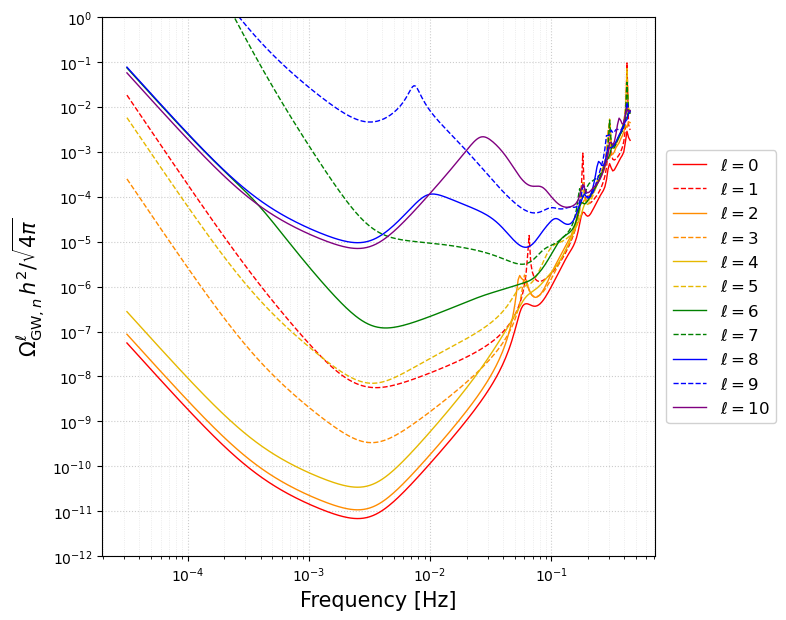

In [27]:
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, LogFormatterMathtext

# Matplotlib look close to your screenshot
plt.style.use("default")   # or "seaborn-v0_8-whitegrid"

fig, ax = plt.subplots(figsize=(8.2, 7))

# Paired colors: (0,1), (2,3), ..., (10)
pair_colors = [
    "red",         # l = 0,1
    "darkorange",  # l = 2,3
    "#E6B800",     # l = 4,5
    "green",       # l = 6,7
    "blue",        # l = 8,9
    "purple",      # l = 10
]

for ell in range(LMAX + 1):
    color = pair_colors[ell // 2]
    ls = "-" if ell % 2 == 0 else "--"

    ax.loglog(
        f,
        figure9_curves[ell],
        color=color,
        linestyle=ls,
        linewidth=1.0,
        label=rf"$\ell={ell}$",
    )

ax.set_xlabel("Frequency [Hz]", fontsize=15)
ax.set_ylabel(r"$\Omega^{\ell}_{{\rm GW},n}\,h^2 / \sqrt{4\pi}$", fontsize=15)
ax.set_ylim(1e-12, 1e0)

ax.grid(True, which="major", linestyle=":", linewidth=0.8, color="0.8")
ax.grid(True, which="minor", linestyle=":", linewidth=0.6, color="0.9")

ax.yaxis.set_major_locator(LogLocator(base=10, subs=(1.0,), numticks=100))
ax.yaxis.set_major_formatter(LogFormatterMathtext(base=10))

# Legend outside, same layout idea as screenshot
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
    fancybox=True,
    framealpha=0.9,
    borderaxespad=0.0,
    fontsize=12
)

# Leave room for the outside legend
fig.subplots_adjust(right=0.80)

plt.show()

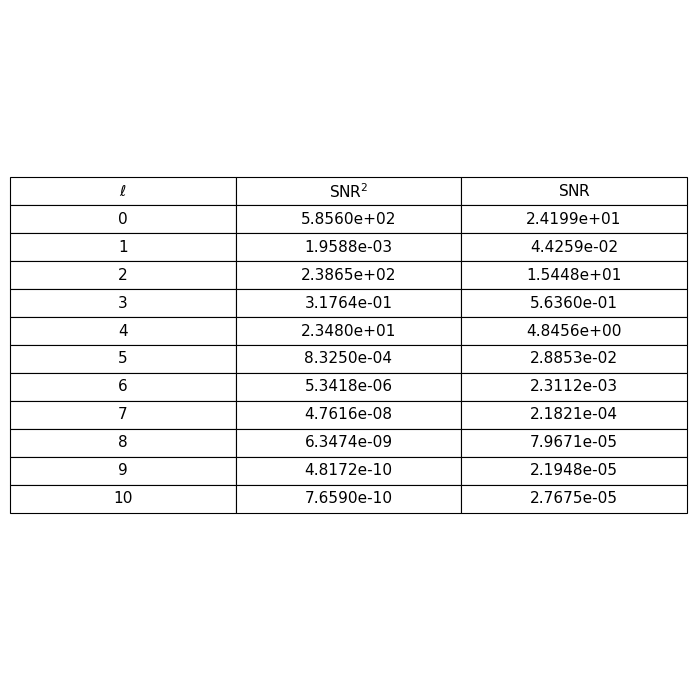

In [4]:
# second: nice table
show_snr_table(snr_results)

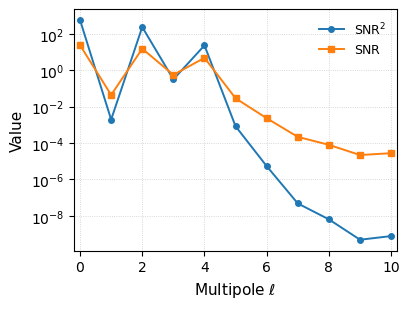

In [28]:
import numpy as np
import matplotlib.pyplot as plt

ell = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
snr2 = np.array([5.8560e+02, 1.9588e-03, 2.3865e+02, 3.1764e-01, 2.3480e+01,
                 8.3250e-04, 5.3418e-06, 4.7616e-08, 6.3474e-09, 4.8172e-10,
                 7.6590e-10])
snr = np.array([2.4199e+01, 4.4259e-02, 1.5448e+01, 5.6360e-01, 4.8456e+00,
                2.8853e-02, 2.3112e-03, 2.1821e-04, 7.9671e-05, 2.1948e-05,
                2.7675e-05])

fig, ax = plt.subplots(figsize=(4.2, 3.2))

ax.plot(ell, snr2, marker='o', linewidth=1.4, markersize=4, label=r'$\mathrm{SNR}^2$')
ax.plot(ell, snr, marker='s', linewidth=1.4, markersize=4, label=r'$\mathrm{SNR}$')

ax.set_yscale('log')
ax.set_xlabel(r'Multipole $\ell$', fontsize=11)
ax.set_ylabel('Value', fontsize=11)

ax.grid(True, which='major', linestyle=':', linewidth=0.6, color='0.8')
ax.grid(True, which='minor', linestyle=':', linewidth=0.4, color='0.9')

ax.legend(fontsize=9, frameon=False)
ax.set_xlim(-0.2, 10.2)

plt.tight_layout()
plt.show()

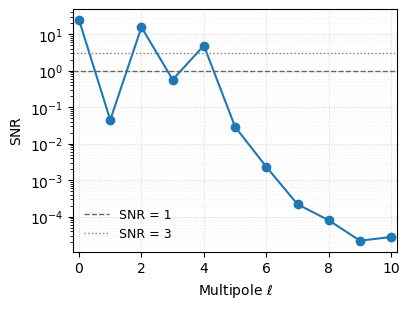

In [29]:
import numpy as np
import matplotlib.pyplot as plt

ell = np.arange(11)
snr = np.array([
    2.4199e+01, 4.4259e-02, 1.5448e+01, 5.6360e-01, 4.8456e+00,
    2.8853e-02, 2.3112e-03, 2.1821e-04, 7.9671e-05, 2.1948e-05,
    2.7675e-05
])

fig, ax = plt.subplots(figsize=(4.2, 3.2))

ax.plot(ell, snr, marker='o', linewidth=1.5)
ax.axhline(1.0, linestyle='--', linewidth=1.0, color='0.4', label='SNR = 1')
ax.axhline(3.0, linestyle=':', linewidth=1.0, color='0.5', label='SNR = 3')

ax.set_yscale('log')
ax.set_xlabel(r'Multipole $\ell$')
ax.set_ylabel(r'$\mathrm{SNR}$')
ax.set_xlim(-0.2, 10.2)

ax.grid(True, which='major', linestyle=':', linewidth=0.6, color='0.8')
ax.grid(True, which='minor', linestyle=':', linewidth=0.4, color='0.9')
ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

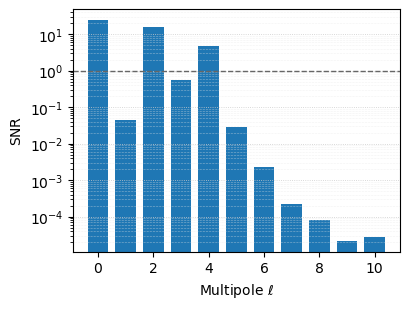

In [30]:
fig, ax = plt.subplots(figsize=(4.2, 3.2))

bars = ax.bar(ell, snr, width=0.75)
ax.axhline(1.0, linestyle='--', linewidth=1.0, color='0.4')

ax.set_yscale('log')
ax.set_xlabel(r'Multipole $\ell$')
ax.set_ylabel(r'$\mathrm{SNR}$')

ax.grid(True, which='major', axis='y', linestyle=':', linewidth=0.6, color='0.8')
ax.grid(True, which='minor', axis='y', linestyle=':', linewidth=0.4, color='0.9')

plt.tight_layout()
plt.show()

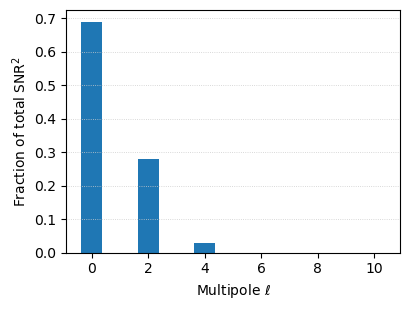

In [31]:
snr2 = np.array([
    5.8560e+02, 1.9588e-03, 2.3865e+02, 3.1764e-01, 2.3480e+01,
    8.3250e-04, 5.3418e-06, 4.7616e-08, 6.3474e-09, 4.8172e-10,
    7.6590e-10
])

frac = snr2 / snr2.sum()

fig, ax = plt.subplots(figsize=(4.2, 3.2))
ax.bar(ell, frac, width=0.75)

ax.set_xlabel(r'Multipole $\ell$')
ax.set_ylabel(r'Fraction of total $\mathrm{SNR}^2$')

ax.grid(True, axis='y', linestyle=':', linewidth=0.6, color='0.8')

plt.tight_layout()
plt.show()

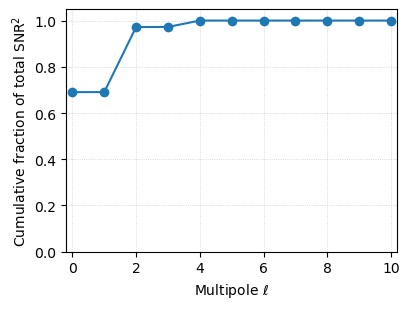

In [32]:
cum = np.cumsum(snr2) / np.sum(snr2)

fig, ax = plt.subplots(figsize=(4.2, 3.2))
ax.plot(ell, cum, marker='o', linewidth=1.5)

ax.set_xlabel(r'Multipole $\ell$')
ax.set_ylabel(r'Cumulative fraction of total $\mathrm{SNR}^2$')
ax.set_ylim(0, 1.05)
ax.set_xlim(-0.2, 10.2)

ax.grid(True, linestyle=':', linewidth=0.6, color='0.8')

plt.tight_layout()
plt.show()

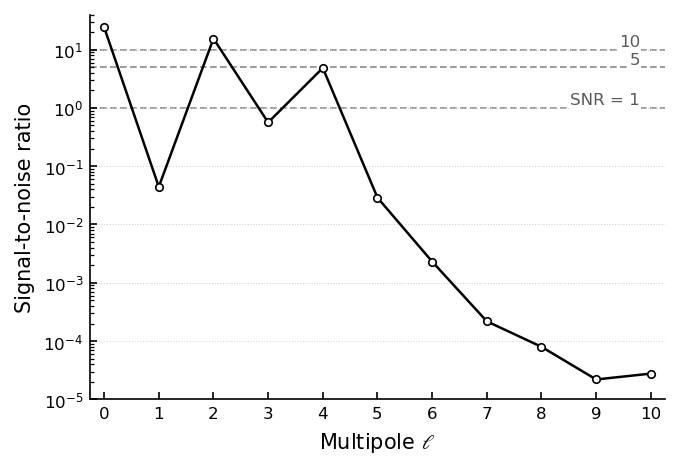

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import LogLocator, LogFormatterMathtext, NullFormatter

# -----------------------
# Data
# -----------------------
ell = np.arange(11)
snr = np.array([
    2.4199e+01, 4.4259e-02, 1.5448e+01, 5.6360e-01, 4.8456e+00,
    2.8853e-02, 2.3112e-03, 2.1821e-04, 7.9671e-05, 2.1948e-05,
    2.7675e-05
])

# -----------------------
# Style: compact, journal-friendly
# -----------------------
mpl.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "font.size": 9,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,
    "xtick.minor.size": 2.0,
    "ytick.minor.size": 2.0,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,
    "mathtext.fontset": "dejavuserif",
})

# -----------------------
# Figure
# -----------------------
fig, ax = plt.subplots(figsize=(4.6, 3.2))

# Main series: line + small markers to show actual sampled multipoles
ax.plot(
    ell, snr,
    color="black",
    linewidth=1.2,
    marker="o",
    markersize=3.6,
    markerfacecolor="white",
    markeredgecolor="black",
    markeredgewidth=0.8,
    zorder=3,
)

# Threshold lines
thresholds = [1, 5, 10]
for y in thresholds:
    ax.axhline(
        y,
        color="0.55",
        linestyle=(0, (4, 2)),
        linewidth=0.8,
        zorder=1,
    )

# Put threshold labels inside the axes, aligned to the right edge
x_right = ell.max() - 0.2
for y, label in zip(thresholds, ["SNR = 1", "5", "10"]):
    ax.text(
        x_right, y, label,
        ha="right", va="bottom",
        fontsize=8, color="0.35",
        bbox=dict(facecolor="white", edgecolor="none", pad=0.6),
        zorder=4,
    )

# Axes scaling and limits
ax.set_yscale("log")
ax.set_xlim(-0.25, 10.25)
ax.set_ylim(1e-5, 4e1)

# Labels
ax.set_xlabel(r"Multipole $\ell$")
ax.set_ylabel(r"Signal-to-noise ratio")

# Integer x ticks only
ax.set_xticks(np.arange(0, 11, 1))

# Log tick formatting
ax.yaxis.set_major_locator(LogLocator(base=10.0))
ax.yaxis.set_major_formatter(LogFormatterMathtext(base=10.0))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1))
ax.yaxis.set_minor_formatter(NullFormatter())

# Light grid on major y only
ax.grid(axis="y", which="major", linestyle=":", linewidth=0.5, color="0.82")
ax.grid(axis="x", which="major", visible=False)

# Clean frame, but keep left/bottom strong
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("snr_vs_multipole.pdf", bbox_inches="tight")
plt.savefig("snr_vs_multipole.png", bbox_inches="tight")
plt.show()

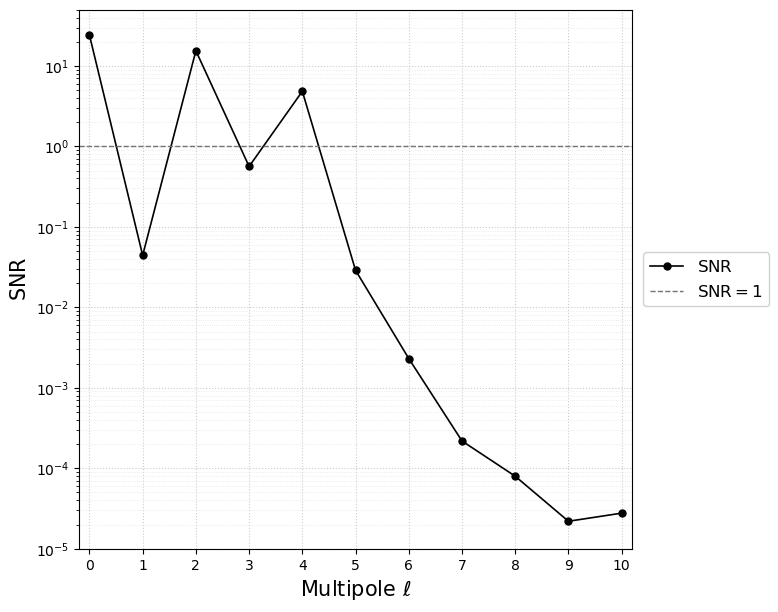

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, LogFormatterMathtext, NullFormatter

# -----------------------
# Data
# -----------------------
ell = np.arange(11)
snr = np.array([
    2.4199e+01, 4.4259e-02, 1.5448e+01, 5.6360e-01, 4.8456e+00,
    2.8853e-02, 2.3112e-03, 2.1821e-04, 7.9671e-05, 2.1948e-05,
    2.7675e-05
])

# -----------------------
# Style to match your other figure
# -----------------------
plt.style.use("default")

fig, ax = plt.subplots(figsize=(8.2, 7))

# Main curve
ax.semilogy(
    ell,
    snr,
    color="black",
    linestyle="-",
    linewidth=1.2,
    marker="o",
    markersize=5,
    label=r"$\mathrm{SNR}$"
)

# Threshold lines in the same restrained style
threshold_styles = [
    (1,  "--", "0.45")
]

for y, ls, c in threshold_styles:
    ax.axhline(y, color=c, linestyle=ls, linewidth=1.0)

# Labels
ax.set_xlabel(r"Multipole $\ell$", fontsize=15)
ax.set_ylabel(r"$\mathrm{SNR}$", fontsize=15)

# Limits
ax.set_xlim(-0.2, 10.2)
ax.set_ylim(1e-5, 5e1)

# Grid like your other plot
ax.grid(True, which="major", linestyle=":", linewidth=0.8, color="0.8")
ax.grid(True, which="minor", linestyle=":", linewidth=0.6, color="0.9")

# Log tick formatting
ax.yaxis.set_major_locator(LogLocator(base=10, subs=(1.0,), numticks=100))
ax.yaxis.set_major_formatter(LogFormatterMathtext(base=10))
ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1, numticks=100))
ax.yaxis.set_minor_formatter(NullFormatter())

# Integer multipole ticks
ax.set_xticks(np.arange(0, 11, 1))

# Legend outside to match your existing layout
handles = [ax.lines[0]]
labels = [r"$\mathrm{SNR}$"]

# Add proxy lines for thresholds
for y in [1]:
    handles.append(plt.Line2D([], [], color="0.45", linestyle="--", linewidth=1.0))
    labels.append(rf"$\mathrm{{SNR}}={y}$")

ax.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
    fancybox=True,
    framealpha=0.9,
    borderaxespad=0.0,
    fontsize=12
)

# Leave room for outside legend
fig.subplots_adjust(right=0.80)

plt.show()